![Spark Logo](http://spark-mooc.github.io/web-assets/images/ta_Spark-logo-small.png)
![Python Logo](http://spark-mooc.github.io/web-assets/images/python-logo-master-v3-TM-flattened_small.png)

> Apache Spark is a fast and general-purpose cluster computing system. It provides high-level APIs in Java, Scala, Python and R, and an optimized engine that supports general execution graphs. It also supports a rich set of higher-level tools including Spark SQL for SQL and structured data processing, MLlib for machine learning, GraphX for graph processing, and Spark Streaming. 
- http://spark.apache.org/

![Analytics Leader Diagram](https://pwu6iw.dm2301.livefilestore.com/y4mwKSdru-QfL8ZKV5oFEtpjOb9CIrMIjV076zefaF7oiLUHmpOjqzZvbO1W15Q6qn4B-MGqenDjIKaDDirtOKdgNtzBi74FEd1_c0DtpmLyCsS5l7FFKCihUmbXnOrPW2rOFA2TAU2uIs6XUvnli023qpZStuCHR4c_1sDYG0PRijLJ5AZCLiwGRm39-8rJjgHZFqeSizAGn2FleZm3ruqnw?width=489&height=358&cropmode=none)<br>
> **Source:** [Data Science Central](http://www.datasciencecentral.com/profiles/blogs/difference-between-machine-learning-data-science-ai-deep-learning?utm_content=bufferdf54f&utm_medium=social&utm_source=linkedin.com&utm_campaign=buffer)


### Basics to Data Science Blogs

1. [How to do Data Science](https://blogs.technet.microsoft.com/machinelearning/2016/03/28/how-to-do-data-science/)
2. [What is data Cleansing?](https://www.linkedin.com/pulse/what-data-cleansing-jeffrey-strickland-ph-d-cmsp)
3. [Apache Spark Architecture v2.0](https://jaceklaskowski.gitbooks.io/mastering-apache-spark/content/spark-architecture.html)
4. [What is Machine Learning?](https://www.technologyreview.com/s/612437/what-is-machine-learning-we-drew-you-another-flowchart/)
5. [Is this Artificial Intelligence (AI)?](https://www.technologyreview.com/s/612404/is-this-ai-we-drew-you-a-flowchart-to-work-it-out/)
6. [Deep Learning Pipeline @Databrick](https://docs.databricks.com/applications/deep-learning/deep-learning-pipelines.html)
7. [A Vision for Making Deep Learning Simple](https://databricks.com/blog/2017/06/06/databricks-vision-simplify-large-scale-deep-learning.html)
8. [A simple way to share Jupyter Notebooks](https://nbviewer.jupyter.org/)
9. [Python Scalable Outlier Detection](https://github.com/yzhao062/pyod#quick-introduction)
10. [Scikit-Learn](https://scikit-learn.org/stable/index.html)
11. [Pandas](https://pandas.pydata.org/)
12. [Matplotlib](https://matplotlib.org/)
13. [Bokeh](https://bokeh.pydata.org/en/latest/)
14. [NumPy](http://www.numpy.org/)
15. [OpenCV](https://github.com/opencv/opencv)
16. [Neural-Style-TF](https://github.com/cysmith/neural-style-tf)
17. [Python Outlier Detection (PyOD)](https://github.com/yzhao062/pyod)
18. [Data Science Python Notebook](https://github.com/donnemartin/data-science-ipython-notebooks)

# Checking Python and Apache Spark Version

In [1]:
import sys
print("Python Version: %s; Apache Spark Version: %s" %(sys.version[0:6], spark.version))

Python Version: 3.6.8 ; Apache Spark Version: 2.4.0


# Define path to datasets

In [2]:
# Define path to data
path = 'dataset'

# Read JSON File Format

In [3]:
dfJSON = spark.read.json(path + "/people.json")
dfJSON.show()

+----+-------+
| age|   name|
+----+-------+
|null|Michael|
|  30|   Andy|
|  19| Justin|
+----+-------+



# Read CSV file format

In [4]:
dfCSV = sqlContext.read.format('csv').\
        options(header = 'true', sep = ';', inferSchema = 'true').\
        load(path + '/people.csv')
        
dfCSV.show()

+-----+---+---------+
| name|age|      job|
+-----+---+---------+
|Jorge| 30|Developer|
|  Bob| 32|Developer|
+-----+---+---------+



# Select Certain Field(s) From Data Frame

In [5]:
dfCSV.select('name','job', 'age').show()

+-----+---------+---+
| name|      job|age|
+-----+---------+---+
|Jorge|Developer| 30|
|  Bob|Developer| 32|
+-----+---------+---+



# Read Solubility Data in CSV Format

In [6]:
eSolubility = sqlContext.read.format('csv').\
              options(header = 'true', inferSchema = 'true').\
              load(path + '/solubility_fixed_01.csv')

In [7]:
eSolubility.cache()
eSolubility.printSchema()

root
 |-- Name: string (nullable = true)
 |-- msol: double (nullable = true)
 |-- nAcid: double (nullable = true)
 |-- ALogP: double (nullable = true)
 |-- ALogp2: double (nullable = true)
 |-- AMR: double (nullable = true)
 |-- apol: double (nullable = true)
 |-- naAromAtom: double (nullable = true)
 |-- nAromBond: double (nullable = true)
 |-- nAtom: double (nullable = true)
 |-- nHeavyAtom: double (nullable = true)
 |-- nH: double (nullable = true)
 |-- nB: double (nullable = true)
 |-- nC: double (nullable = true)
 |-- nN: double (nullable = true)
 |-- nO: double (nullable = true)
 |-- nS: double (nullable = true)
 |-- nP: double (nullable = true)
 |-- nF: double (nullable = true)
 |-- nCl: double (nullable = true)
 |-- nBr: double (nullable = true)
 |-- nI: double (nullable = true)
 |-- nX: double (nullable = true)
 |-- ATS0m: double (nullable = true)
 |-- ATS1m: double (nullable = true)
 |-- ATS2m: double (nullable = true)
 |-- ATS3m: double (nullable = true)
 |-- ATS4m: double (

# Fill NULL Records With Certain Value

In [8]:
eSolubility = eSolubility.fillna(0.0000)

# Select Certain Columns For Display

In [9]:
eSolubility.select('Name', 'msol', 'nAcid', 'ALogP', 'AMR', 'apol').show(10)

+--------------------+-----+-----+-------+-------+-------+
|                Name| msol|nAcid|  ALogP|    AMR|   apol|
+--------------------+-----+-----+-------+-------+-------+
|1,1,1,2-Tetrachlo...|-2.18|  0.0| 2.4441|31.2668|13.5736|
|1,1,1-Trichloroet...| -2.0|  0.0| 2.0293|26.2173|  10.06|
|1,1,2,2-Tetrachlo...|-1.74|  0.0| 2.3992|30.7638|13.5736|
|1,1,2-Trichloroet...|-1.48|  0.0| 1.9555|25.7097|12.0604|
|1,1,2-Trichlorotr...|-3.04|  0.0| 2.7863|27.3736| 11.731|
|  1,1-Dichloroethane|-1.29|  0.0| 1.5407|20.6602|10.5472|
|1,1-Dichloroethylene|-1.64|  0.0|  1.688|20.4606| 9.2136|
|1,2,3,4-Tetrachlo...|-4.57|  0.0| 2.9772|22.4624|20.6136|
|1,2,3,4-Tetrahydr...|-4.37|  0.0|-0.4512| 15.554|25.6015|
|1,2,3,5-Tetrachlo...|-4.63|  0.0| 2.9772|22.4624|20.6136|
+--------------------+-----+-----+-------+-------+-------+
only showing top 10 rows



In [10]:
# PySpark dimension of dataframe how-to
print ("PySpark dataframe dimension: %d rows, %d columns" %(eSolubility.count(), len(eSolubility.columns)))

PySpark dataframe dimension: 1131 rows, 1446 columns


In [11]:
# Select specific fieldnames and display the first row
eSolubility.select('Name', 'msol', 'nAcid', 'ALogP', 'AMR', 'apol').first()

Row(Name='1,1,1,2-Tetrachloroethane', msol=-2.18, nAcid=0.0, ALogP=2.4441, AMR=31.2668, apol=13.5736)

In [12]:
# Select specific fieldnames and display the first two rows
eSolubility.select('Name', 'msol', 'nAcid', 'ALogP', 'AMR', 'apol').take(2)

[Row(Name='1,1,1,2-Tetrachloroethane', msol=-2.18, nAcid=0.0, ALogP=2.4441, AMR=31.2668, apol=13.5736),
 Row(Name='1,1,1-Trichloroethane', msol=-2.0, nAcid=0.0, ALogP=2.0293, AMR=26.2173, apol=10.06)]

# Check Pandas's Version

In [13]:
import pandas as pd
pd.__version__

'0.23.4'

# Modin Pandas To Speed Up CSV Loading Time
## See also https://github.com/modin-project/modin

In [14]:
# import modin.pandas as pd
# pd.__version__

# Convert PySpark Dataframe to Pandas Dataframe

In [15]:
eSolubility_pdf = eSolubility.toPandas()

# Pandas Dataframe Dimension How-to

In [16]:
print ("Panda dataframe dimension is %d rows, %d columns." %(eSolubility_pdf.shape[0], eSolubility_pdf.shape[1]))

Panda dataframe dimension is 1131 rows, 1446 columns.


# Selecting First Ten Rows & First Four Columns

In [17]:
eSolubility_pdf.iloc[:5, :4]

,Name,msol,nAcid,ALogP
0,"1,1,1,2-Tetrachloroethane",-2.18,0.0,2.4441
1,"1,1,1-Trichloroethane",-2.00,0.0,2.0293
2,"1,1,2,2-Tetrachloroethane",-1.74,0.0,2.3992
3,"1,1,2-Trichloroethane",-1.48,0.0,1.9555
4,"1,1,2-Trichlorotrifluoroethane",-3.04,0.0,2.7863


# Vertorize & Transform Data

In [18]:
import numpy as np
import scipy.sparse as sps
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

ignore = ['Name', 'msol']
colNames = eSolubility.schema.names
selCols = range(3,1440)

assembler  = VectorAssembler(inputCols = [colNames[x] for x in selCols],
                             outputCol = 'features')

data = assembler.transform(eSolubility)

In [19]:
data.select("Name", "msol", "features").show(5)

+--------------------+-----+--------------------+
|                Name| msol|            features|
+--------------------+-----+--------------------+
|1,1,1,2-Tetrachlo...|-2.18|(1437,[0,1,2,3,6,...|
|1,1,1-Trichloroet...| -2.0|(1437,[0,1,2,3,6,...|
|1,1,2,2-Tetrachlo...|-1.74|(1437,[0,1,2,3,6,...|
|1,1,2-Trichloroet...|-1.48|(1437,[0,1,2,3,6,...|
|1,1,2-Trichlorotr...|-3.04|(1437,[0,1,2,3,6,...|
+--------------------+-----+--------------------+
only showing top 5 rows



# Remove unwanted features (data -> mlData)

In [20]:
mlData = data.select('features', 'msol')
mlData.show(5)

+--------------------+-----+
|            features| msol|
+--------------------+-----+
|(1437,[0,1,2,3,6,...|-2.18|
|(1437,[0,1,2,3,6,...| -2.0|
|(1437,[0,1,2,3,6,...|-1.74|
|(1437,[0,1,2,3,6,...|-1.48|
|(1437,[0,1,2,3,6,...|-3.04|
+--------------------+-----+
only showing top 5 rows



In [21]:
mlData.printSchema()

root
 |-- features: vector (nullable = true)
 |-- msol: double (nullable = false)



In [22]:
splits = mlData.randomSplit([0.7, 0.3])
mlData_train_df = splits[0]
mlData_test_df = splits[1]

# Linear Regression Modeling

In [23]:
from pyspark.ml.regression import LinearRegression
from time import *

start_time = time()

lr = LinearRegression(featuresCol ='features', 
                      labelCol = 'msol', 
                      maxIter = 1000, 
                      regParam = 0.01, 
                      elasticNetParam = 0.01)

lr_model = lr.fit(mlData)
print("Coefficients: " + str(lr_model.coefficients))
print("Intercept: " + str(lr_model.intercept))


Coefficients: [-0.035884206489783604,-0.019519949483934918,0.002558600770757604,-0.0004885260316700519,0.0003497352296855783,0.002599719267663873,-0.00015058819483027366,-0.000990824068393432,0.0005860459932142313,0.0,-0.0014131510165298674,0.01853593496754947,0.01436840500678022,0.00852555650427777,-0.16954505294873856,-0.06346586919209027,-0.041186184294683195,-0.06893536302936992,0.06893386857968803,-0.04401059153436112,-3.6070179803196515e-06,-3.8486181007679056e-06,-1.056277910373911e-06,-1.4701681545001397e-06,-1.3220186374843825e-06,-4.368774906679534e-06,4.882137104321016e-07,-4.312964870645874e-06,-7.5468102292313e-06,-3.04471812766375e-06,-1.9247049849315887e-06,-1.1104434676075215e-06,-5.89715633094596e-07,-3.525454997046746e-08,3.0666932111109817e-07,6.192684854626453e-07,1.4183456522838654e-07,-1.5432273994962288e-06,-1.3683409543128945e-05,-1.4499797675966864e-05,-7.559183421714484e-06,-6.066685714145724e-06,4.435774566193338e-06,1.9391376317979712e-05,3.1208428981398964e

In [24]:
trainingSummary = lr_model.summary
print("RMSE: %f" % trainingSummary.rootMeanSquaredError)
print("r2: %f" % trainingSummary.r2)

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

RMSE: 0.331271
r2: 0.975192
Time to evaluate model: 14 seconds


In [25]:
mlData.describe().show()

+-------+------------------+
|summary|              msol|
+-------+------------------+
|  count|              1131|
|   mean|-3.062881520778073|
| stddev|2.1041537605168386|
|    min|             -11.6|
|    max|              1.58|
+-------+------------------+



# Decision Tree Regression Modeling

In [26]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorIndexer
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import DecisionTreeRegressor

start_time = time()

featureIndexer = VectorIndexer(inputCol = "features", 
                               outputCol = "indexedFeatures",
                               maxCategories = 4).fit(mlData)

dt = DecisionTreeRegressor(featuresCol = 'indexedFeatures',
                           labelCol = 'msol', 
                           maxDepth = 10, maxBins = 32)

pipeline = Pipeline(stages = [featureIndexer, dt])

dt_model = pipeline.fit(mlData)
dt_predictions = dt_model.transform(mlData)

dt_evaluator = RegressionEvaluator(labelCol = "msol", 
                                   predictionCol = "prediction", 
                                   metricName = "rmse")

rmse = dt_evaluator.evaluate(dt_predictions)
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

Root Mean Squared Error (RMSE) on test data = 0.221916
Time to evaluate model: 18 seconds


In [27]:
dt_predictions.show(4)

+--------------------+-----+--------------------+-------------------+
|            features| msol|     indexedFeatures|         prediction|
+--------------------+-----+--------------------+-------------------+
|(1437,[0,1,2,3,6,...|-2.18|(1437,[0,1,2,3,6,...|-2.2257647058823533|
|(1437,[0,1,2,3,6,...| -2.0|(1437,[0,1,2,3,6,...|-2.2257647058823533|
|(1437,[0,1,2,3,6,...|-1.74|(1437,[0,1,2,3,6,...|-2.2257647058823533|
|(1437,[0,1,2,3,6,...|-1.48|(1437,[0,1,2,3,6,...|-1.4533333333333338|
+--------------------+-----+--------------------+-------------------+
only showing top 4 rows



In [28]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

msol = dt_predictions.select("msol").toPandas()
prediction = dt_predictions.select("prediction").toPandas()
ax1.plot(msol, prediction, 'r.')

ax1.set_xlim((-12.5, 2.0))
ax1.set_ylim((-12.5, 2.0))
ax1.set_title(("Solubility (Predicted vs. Measured)"))
ax1.set_xlabel("Measured")
ax1.set_ylabel("Predicted")

#display(fig)
plt.show()

<Figure size 640x480 with 1 Axes>

# Random Forest Regression Modeling

In [29]:
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorIndexer
from pyspark.ml.evaluation import RegressionEvaluator

start_time = time()

# Automatically identify categorical features, and index them.
# Set maxCategories so features with > 4 distinct values are treated as continuous.
featureIndexer = VectorIndexer(inputCol = "features", 
                               outputCol = "rf_indexedFeatures", 
                               maxCategories = 4).fit(mlData)


# Train a RandomForest model.
rf = RandomForestRegressor(featuresCol = "rf_indexedFeatures", labelCol = "msol",
                           maxDepth = 10, maxBins = 32, numTrees = 500, maxMemoryInMB = 1024)

# Chain indexer and forest in a Pipeline
pipeline = Pipeline(stages=[featureIndexer, rf])

# Train model.  This also runs the indexer.
model = pipeline.fit(mlData)

# Make predictions.
rfPredictions = model.transform(mlData)

# Select example rows to display.
rfPredictions.select("prediction", "msol", "features", "rf_indexedFeatures").show(4)

# Select (prediction, true label) and compute test error
evaluator = RegressionEvaluator(labelCol = "msol", 
                                predictionCol = "prediction", 
                                metricName = "rmse")
rmse = evaluator.evaluate(rfPredictions)
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

rfModel = model.stages[1]
print(rfModel)  # summary only

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

+-------------------+-----+--------------------+--------------------+
|         prediction| msol|            features|  rf_indexedFeatures|
+-------------------+-----+--------------------+--------------------+
| -2.088524925536547|-2.18|(1437,[0,1,2,3,6,...|(1437,[0,1,2,3,6,...|
|-1.8734615420035834| -2.0|(1437,[0,1,2,3,6,...|(1437,[0,1,2,3,6,...|
|-1.9260587142176502|-1.74|(1437,[0,1,2,3,6,...|(1437,[0,1,2,3,6,...|
| -1.624932454223119|-1.48|(1437,[0,1,2,3,6,...|(1437,[0,1,2,3,6,...|
+-------------------+-----+--------------------+--------------------+
only showing top 4 rows

Root Mean Squared Error (RMSE) on test data = 0.261259
RandomForestRegressionModel (uid=RandomForestRegressor_a57594ac75b4) with 500 trees
Time to evaluate model: 996 seconds


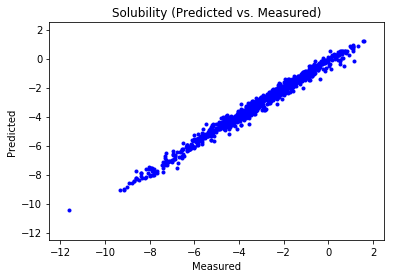

In [30]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

msol = rfPredictions.select("msol").toPandas()
prediction = rfPredictions.select("prediction").toPandas()
ax1.plot(msol, prediction, 'b.')

ax1.set_xlim((-12.5, 2.5))
ax1.set_ylim((-12.5, 2.5))
ax1.set_title(("Solubility (Predicted vs. Measured)"))
ax1.set_xlabel("Measured")
ax1.set_ylabel("Predicted")

#display(fig)
plt.show()

# Principle Component Analysis (PCA)

### **_PCA with training dataset_**

In [31]:
from pyspark.ml.feature import PCA
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StandardScaler

start_time = time()

selColumns = range(3,1440)
colNames = eSolubility.schema.names

assembler  = VectorAssembler(inputCols = [colNames[i] for i in selColumns],
                             outputCol = 'features')
                             
pcaData = assembler.transform(eSolubility) # transforming variable columns into one column of features

# Scale features to have zero mean and unit standard deviation
standardizer = StandardScaler(withMean = True, withStd = True,
                              inputCol = 'features',
                              outputCol = 'std_features')

model = standardizer.fit(pcaData)
output = model.transform(pcaData)
pcaData = output.select(['std_features', 'msol', 'Name', 'features', 'std_features'])

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

Time to evaluate model: 1 seconds


In [32]:
start_time = time()

pca = PCA(k = 40, inputCol = "std_features", outputCol = "pcaFeatures")
model = pca.fit(pcaData)
transformed = model.transform(pcaData).select('Name', 'msol', 'pcaFeatures')
transformed.select('Name', 'msol', 'pcaFeatures').show(4, truncate = True)

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

+--------------------+-----+--------------------+
|                Name| msol|         pcaFeatures|
+--------------------+-----+--------------------+
|1,1,1,2-Tetrachlo...|-2.18|[-22.526498685774...|
|1,1,1-Trichloroet...| -2.0|[-25.473622306813...|
|1,1,2,2-Tetrachlo...|-1.74|[-23.063248593496...|
|1,1,2-Trichloroet...|-1.48|[-25.089349684165...|
+--------------------+-----+--------------------+
only showing top 4 rows

Time to evaluate model: 14 seconds


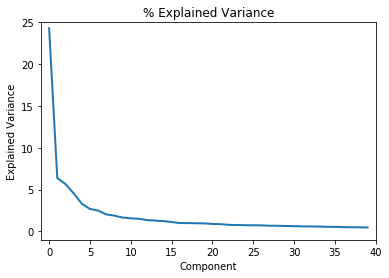

In [33]:
fig, ax1 = plt.subplots()

ax1.plot(model.explainedVariance*100, linewidth = 2.0)

ax1.set_xlim((-1, 40))
ax1.set_ylim((-1, 25))
ax1.set_title(("% Explained Variance"))
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained Variance")

#display(fig)
plt.show()

In [34]:
ptExplainedVariance = (model.explainedVariance).sum() * 100
numComponents = len(model.explainedVariance)
print ("Percentage explained variance: %d" %ptExplainedVariance)
print ("Number of components being used: %d" %numComponents)

Percentage explained variance: 80
Number of components being used: 40


### **_PCA with testing dataset_**

In [35]:
start_time = time()

# Applying principle components from training dataset to testing dataset
testDataset = assembler.transform(eSolubility)
testDatasetModel = standardizer.fit(testDataset)
testDatasetOutput = testDatasetModel.transform(testDataset)

pcaTestDatasetModel = pca.fit(testDatasetOutput)
transformedTestDataset = pcaTestDatasetModel.transform(testDatasetOutput)

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

Time to evaluate model: 13 seconds


In [36]:
transformedTestDataset.select('Name', 'msol', 'pcaFeatures').show(4, truncate=True)

+--------------------+-----+--------------------+
|                Name| msol|         pcaFeatures|
+--------------------+-----+--------------------+
|1,1,1,2-Tetrachlo...|-2.18|[-22.526498685774...|
|1,1,1-Trichloroet...| -2.0|[-25.473622306813...|
|1,1,2,2-Tetrachlo...|-1.74|[-23.063248593496...|
|1,1,2-Trichloroet...|-1.48|[-25.089349684165...|
+--------------------+-----+--------------------+
only showing top 4 rows



# Random Forest Regression Modeling

### PCA --> RF with training dataset

In [37]:
from pyspark.ml import Pipeline
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorIndexer
from pyspark.ml.evaluation import RegressionEvaluator

start_time = time()


# Automatically identify categorical features, and index them.
# Set maxCategories so features with > 4 distinct values are treated as continuous.
featureIndexer = VectorIndexer(inputCol = "pcaFeatures",
                               outputCol = "pca_indexedFeatures", 
                               maxCategories = 4).fit(transformed)


# Train a RandomForest model. maxDepth=10, maxBins=32, numTrees=500 tend to have good RMSE
rf = RandomForestRegressor(featuresCol = "pca_indexedFeatures", labelCol = "msol",
                           maxDepth = 15, maxBins = 32, numTrees = 500, maxMemoryInMB = 1024)

# Chain indexer and forest in a Pipeline
pipeline = Pipeline(stages = [featureIndexer, rf])

# Train model.  This also runs the indexer.
pcaRFModel = pipeline.fit(transformed)

# Make predictions.
rfPredictions = pcaRFModel.transform(transformed)

# Select example rows to display.
rfPredictions.select("prediction", "msol", "pca_indexedFeatures").show(5)

# Select (prediction, true label) and compute test error
evaluator = RegressionEvaluator(labelCol = "msol", 
                                predictionCol = "prediction", 
                                metricName = "rmse")

rmse = evaluator.evaluate(rfPredictions)
print("Root Mean Squared Error (RMSE) on test data = %g" % rmse)

rfModel = pcaRFModel.stages[1]
print(rfModel)  # summary only


end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

+-------------------+-----+--------------------+
|         prediction| msol| pca_indexedFeatures|
+-------------------+-----+--------------------+
|-1.9725281577933667|-2.18|[-22.526498685774...|
| -1.951320458008656| -2.0|[-25.473622306813...|
|-1.8037270763902802|-1.74|[-23.063248593496...|
|-1.4602505699937802|-1.48|[-25.089349684165...|
|-2.6972081568627346|-3.04|[-15.623933890817...|
+-------------------+-----+--------------------+
only showing top 5 rows

Root Mean Squared Error (RMSE) on test data = 0.299621
RandomForestRegressionModel (uid=RandomForestRegressor_a370a8b95bba) with 500 trees
Time to evaluate model: 109 seconds


### PCA --> RF with testing dataset

In [38]:
# Predicting the test dataset
start_time = time()

rf_transformedTestDataset_Predictions = pcaRFModel.transform(transformedTestDataset)
rf_transformedTestDataset_Predictions.select("prediction", "msol").show(5)

end_time = time()
elapsed_time = end_time - start_time
print ("Time to evaluate model: %d seconds" %elapsed_time)

+-------------------+-----+
|         prediction| msol|
+-------------------+-----+
|-1.9725281577933667|-2.18|
| -1.951320458008656| -2.0|
|-1.8037270763902802|-1.74|
|-1.4602505699937802|-1.48|
|-2.6972081568627346|-3.04|
+-------------------+-----+
only showing top 5 rows

Time to evaluate model: 3 seconds


### Plot prediction result for training dataset

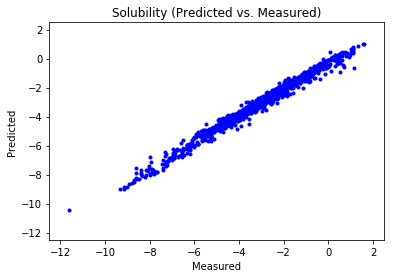

In [39]:
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

msol = rfPredictions.select("msol").toPandas()
prediction = rfPredictions.select("prediction").toPandas()
ax1.plot(msol, prediction, 'b.')

ax1.set_xlim((-12.5, 2.5))
ax1.set_ylim((-12.5, 2.5))
ax1.set_title(("Solubility (Predicted vs. Measured)"))
ax1.set_xlabel("Measured")
ax1.set_ylabel("Predicted")

#display(fig)
plt.show()

### Plot prediction result for testing dataset

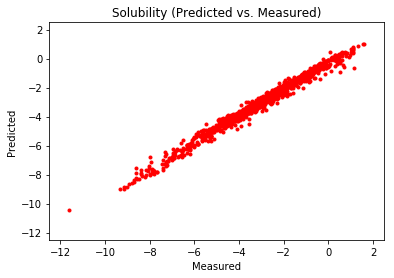

In [40]:
# Plotting result of test dataset
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

msol = rf_transformedTestDataset_Predictions.select("msol").toPandas()
prediction = rf_transformedTestDataset_Predictions.select("prediction").toPandas()
ax1.plot(msol, prediction, 'r.')

ax1.set_xlim((-12.5, 2.5))
ax1.set_ylim((-12.5, 2.5))
ax1.set_title(("Solubility (Predicted vs. Measured)"))
ax1.set_xlabel("Measured")
ax1.set_ylabel("Predicted")

#display(fig)
plt.show()

# Rename Prediction & Label Columns for Pretty Plot

In [41]:
renamedDF = rfPredictions.withColumnRenamed('prediction', 'Predicted')\
                         .withColumnRenamed('msol', 'Measured')
renamedDF.select("Name", "Predicted", "Measured", "pcaFeatures").show(5)

+--------------------+-------------------+--------+--------------------+
|                Name|          Predicted|Measured|         pcaFeatures|
+--------------------+-------------------+--------+--------------------+
|1,1,1,2-Tetrachlo...|-1.9725281577933667|   -2.18|[-22.526498685774...|
|1,1,1-Trichloroet...| -1.951320458008656|    -2.0|[-25.473622306813...|
|1,1,2,2-Tetrachlo...|-1.8037270763902802|   -1.74|[-23.063248593496...|
|1,1,2-Trichloroet...|-1.4602505699937802|   -1.48|[-25.089349684165...|
|1,1,2-Trichlorotr...|-2.6972081568627346|   -3.04|[-15.623933890817...|
+--------------------+-------------------+--------+--------------------+
only showing top 5 rows



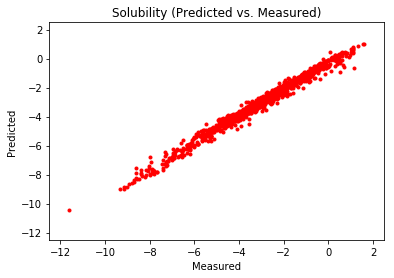

In [42]:
fig, ax1 = plt.subplots()

msol = renamedDF.select("Measured").toPandas()
prediction = renamedDF.select("Predicted").toPandas()
ax1.plot(msol, prediction, 'r.')

ax1.set_xlim((-12.5, 2.5))
ax1.set_ylim((-12.5, 2.5))
ax1.set_title(("Solubility (Predicted vs. Measured)"))
ax1.set_xlabel(("Measured"))
ax1.set_ylabel(("Predicted"))

#display(fig)
plt.show()

# Deep Learning with Tensorflow and Keras

In [43]:
# TensorFlow and Keras

def build_model():
  model = keras.Sequential([
    layers.Dense(64, activation=tf.nn.relu, input_shape=[len(train_dataset.keys())]),
    layers.Dense(64, activation=tf.nn.relu),
    layers.Dense(1)
  ])

  optimizer = tf.train.RMSPropOptimizer(0.001)

  model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae', 'mse'])
  return model

In [44]:
# OpenCV

import cv2

In [45]:
# TensorFlow
import tensorflow as tf